# Part A: Conceptual Understanding

### 1. What is Logistic Regression and why is it suitable for classification?

Logistic Regression is a supervised machine learning algorithm used for classification problems. It predicts the probability of a class using the sigmoid function and converts it into class labels. It is suitable for classification because it outputs values between 0 and 1, representing class probabilities.

---

### 2. Explain classification performance metrics and why accuracy alone is insufficient.

Classification performance metrics include Accuracy, Precision, Recall, F1-Score, and AUC-ROC. Accuracy alone can be misleading, especially for imbalanced datasets, because a model may achieve high accuracy by predicting only the majority class while failing to detect important minority-class instances.

---

### 3. Define Type-I Error and Type-II Error in the context of risk prediction.

**Type-I Error (False Positive):** A low-risk customer is incorrectly classified as high-risk.  
**Type-II Error (False Negative):** A high-risk customer is incorrectly classified as low-risk. In risk prediction, Type-II errors are usually more costly because risky customers may go undetected.

---

### 4. Explain Precision, Recall, F1-Score, TPR, and FPR.

- **Precision:** Percentage of predicted positive cases that are actually positive.
- **Recall (TPR):** Percentage of actual positive cases correctly identified.
- **F1-Score:** Harmonic mean of Precision and Recall.
- **TPR (True Positive Rate):** Same as Recall.
- **FPR (False Positive Rate):** Percentage of actual negative cases incorrectly classified as positive.

---

### 5. What is AUC-ROC and how does it help in evaluating classifiers?

AUC-ROC measures a model's ability to distinguish between classes across different classification thresholds. The ROC curve plots TPR against FPR, while AUC summarizes overall performance. A higher AUC indicates better classification capability.

---

### 6. Why does imbalanced data create problems in classification models?

Imbalanced data causes models to favor the majority class because it dominates the training process. As a result, the model may achieve high accuracy but perform poorly on the minority class, leading to low Recall and missed high-risk cases.

# Part B: Dataset Understanding & Preparation

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import RandomOverSampler , SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score

In [66]:
# Load Dataset
df = pd.read_csv("Risk_Alert_Classifier_Dataset_4600.csv")

print("Dataset Columns:\n")
print(df.columns.tolist())

Dataset Columns:

['customer_id', 'age', 'gender', 'region', 'employment_type', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'last_transaction_date', 'debt_balance_inr', 'risk_status']


In [67]:
df

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,504596,40.0,Male,North,NaN,39337.0,645.0,0.101,0,8.8,49,12591.0,0,0,0,23,2025-09-14,28947,0
4596,504597,35.0,Female,Central,Unemployed,34465.0,622.0,0.325,0,7.3,45,20146.0,3,0,4,18,2025-11-25,32475,0
4597,504598,31.0,Female,East,Self-Employed,NaN,693.0,0.583,1,7.1,36,16338.0,1,1,1,89,2025-09-16,52776,0
4598,504599,43.0,Male,East,Salaried,15000.0,540.0,0.915,4,16.0,60,13870.0,1,1,3,19,2025-09-07,20615,1


In [68]:
# Define Features and Target
X = df.drop("risk_status", axis=1)
y = df["risk_status"]

print("\nTarget Variable:")
print(y.name)

print("\nNumber of Features:", X.shape[1])
print("Number of Records:", X.shape[0])

print("\nFeature Names:")
print(X.columns.tolist())


Target Variable:
risk_status

Number of Features: 18
Number of Records: 4600

Feature Names:
['customer_id', 'age', 'gender', 'region', 'employment_type', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'last_transaction_date', 'debt_balance_inr']


In [69]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

In [71]:
df.isnull().sum()

,0
customer_id,0
age,140
gender,0
region,102
employment_type,144
annual_income_inr,166
credit_score,216
credit_utilization_ratio,147
missed_payments_12m,0
avg_late_payment_days,0


In [72]:
# KNN Imputer
num_cols = ['age', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'monthly_spend_inr']

imputer = KNNImputer(n_neighbors=5)

df[num_cols] = imputer.fit_transform(df[num_cols])

print(df[num_cols].isnull().sum())

age                         0
annual_income_inr           0
credit_score                0
credit_utilization_ratio    0
monthly_spend_inr           0
dtype: int64


In [73]:
categorical_cols = ['region', 'employment_type']

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df[categorical_cols].isnull().sum()

/tmp/ipykernel_4634/2584222640.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,0
region,0
employment_type,0


In [74]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
region,0
employment_type,0
annual_income_inr,0
credit_score,0
credit_utilization_ratio,0
missed_payments_12m,0
avg_late_payment_days,0


In [75]:
# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (3680, 18)
X_test Shape  : (920, 18)
y_train Shape : (3680,)
y_test Shape  : (920,)


# Part C: Baseline Classification Model

In [76]:
df_model = df.copy()

cat_cols = ['gender', 'region', 'employment_type', 'last_transaction_date']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

# Features and Target
X = df_model.drop('risk_status', axis=1)
y = df_model['risk_status']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9891304347826086
Precision: 0.9719626168224299
Recall   : 0.9369369369369369
F1 Score : 0.9541284403669725

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       809
           1       0.97      0.94      0.95       111

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.99      0.99      0.99       920



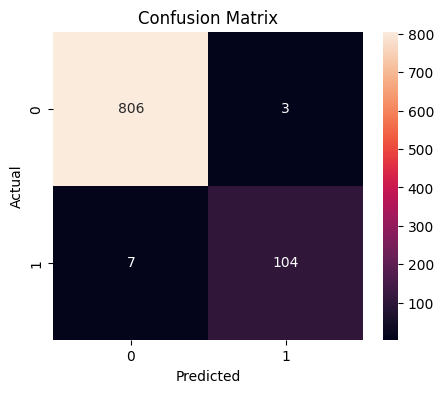

In [78]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [79]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Type-I Error (False Positive) :", fp)
print("Type-II Error (False Negative):", fn)

Type-I Error (False Positive) : 3
Type-II Error (False Negative): 7


### Type-I and Type-II Errors

From the confusion matrix:

- Type-I Error (False Positive): Customers who were actually low-risk but were incorrectly classified as high-risk.
- Type-II Error (False Negative): Customers who were actually high-risk but were incorrectly classified as low-risk.

In this project, Type-II Error is more critical because failing to identify a high-risk customer may lead to financial losses, fraud, or payment defaults. Therefore, reducing False Negatives is a key objective.

# Part D: Handling Imbalanced Data

risk_status
0    4043
1     557
Name: count, dtype: int64


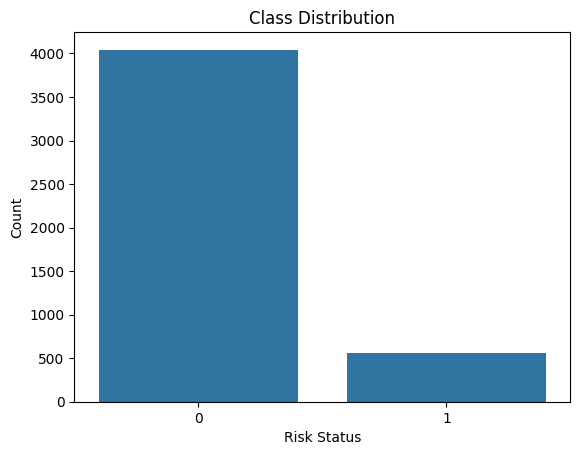

In [80]:
print(df['risk_status'].value_counts())

sns.countplot(x='risk_status', data=df)

plt.title("Class Distribution")
plt.xlabel("Risk Status")
plt.ylabel("Count")
plt.show()

The target variable is imbalanced because the number of low-risk customers is significantly higher than high-risk customers.

This imbalance can bias the model toward the majority class and reduce its ability to correctly identify high-risk customers.

In [81]:
# Under-Sampling
rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(X_train, y_train)

print(y_under.value_counts())

risk_status
0    446
1    446
Name: count, dtype: int64


In [82]:
# Over-Sampling
ros = RandomOverSampler(random_state=42)

X_over, y_over = ros.fit_resample(X_train, y_train)

print(y_over.value_counts())

risk_status
0    3234
1    3234
Name: count, dtype: int64


In [83]:
# SMOTE
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(y_smote.value_counts())

risk_status
0    3234
1    3234
Name: count, dtype: int64


In [84]:
# ADASYN
adasyn = ADASYN(random_state=42)

X_ada, y_ada = adasyn.fit_resample(X_train, y_train)

print(y_ada.value_counts())

risk_status
1    3235
0    3234
Name: count, dtype: int64


In [85]:
samplers = {
    "Under Sampling": RandomUnderSampler(random_state=42),
    "Over Sampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

results = []

# Before Balancing
base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_train, y_train)

base_pred = base_model.predict(X_test)
base_prob = base_model.predict_proba(X_test)[:,1]

results.append([
    "Before Balancing",
    recall_score(y_test, base_pred),
    f1_score(y_test, base_pred),
    roc_auc_score(y_test, base_prob)
])

# All Balancing Methods
for name, sampler in samplers.items():

    X_res, y_res = sampler.fit_resample(X_train, y_train)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_res, y_res)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

comparison = pd.DataFrame(
    results,
    columns=["Method", "Recall", "F1-Score", "AUC-ROC"]
)

comparison

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,Method,Recall,F1-Score,AUC-ROC
0,Before Balancing,0.936937,0.954128,0.998831
1,Under Sampling,0.990991,0.928270,0.998196
2,Over Sampling,0.990991,0.916667,0.998942
3,SMOTE,0.981982,0.935622,0.998797
4,ADASYN,0.990991,0.909091,0.998330


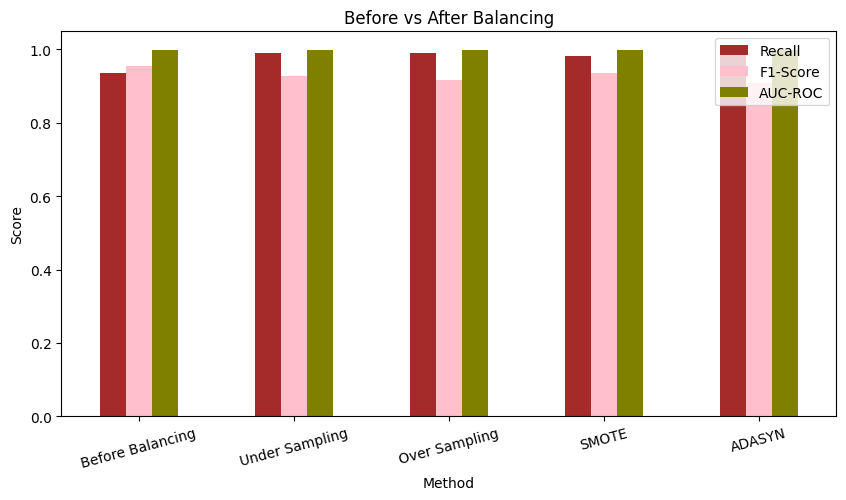

In [86]:
comparison.set_index("Method").plot(
    kind="bar",
    figsize=(10,5),
    color=["brown", "pink", "olive"
    ]
)

plt.title("Before vs After Balancing")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.show()

# Part E: Tree-Based Classification Models

In [87]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9717391304347827
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       809
           1       0.91      0.85      0.88       111

    accuracy                           0.97       920
   macro avg       0.95      0.92      0.93       920
weighted avg       0.97      0.97      0.97       920



In [88]:
train_acc_dt = accuracy_score(
    y_train,
    dt.predict(X_train)
)

test_acc_dt = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Train Accuracy :", train_acc_dt)
print("Decision Tree Test Accuracy  :", test_acc_dt)

Decision Tree Train Accuracy : 1.0
Decision Tree Test Accuracy  : 0.9717391304347827


If training accuracy is much higher than testing accuracy,
the model is overfitting.

A small difference between train and test accuracy indicates
better generalization.

In [89]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9967391304347826
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.98      0.99      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



In [90]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Train Accuracy":[
        accuracy_score(y_train, dt.predict(X_train)),
        accuracy_score(y_train, rf.predict(X_train))
    ],

    "Test Accuracy":[
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Train Accuracy,Test Accuracy
0,Decision Tree,0.971739,1.0,0.971739
1,Random Forest,0.996739,1.0,0.996739


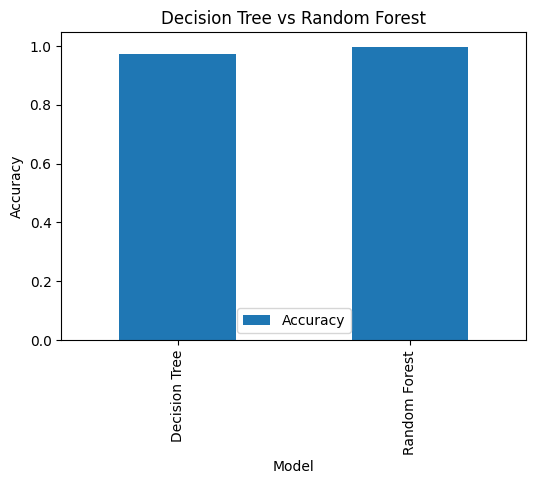

In [91]:
comparison.set_index("Model")[["Accuracy"]].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Decision Tree vs Random Forest")
plt.ylabel("Accuracy")
plt.show()

Random Forest generally performs better than Decision Tree
because it combines multiple trees and reduces overfitting.

Decision Tree is simple and easy to interpret, while Random Forest
provides better accuracy and generalization on unseen data.

The model with higher test accuracy and smaller train-test gap
is considered the better classifier.

# Part F: Hyperparameter Tuning

In [92]:
# Randomized Search CV
dt_params = {
    'max_depth': [3,5,7,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

dt_random.fit(X_train, y_train)

print("Best DT Parameters:")
print(dt_random.best_params_)
print("Best DT Score:", dt_random.best_score_)

Best DT Parameters:
{'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None}
Best DT Score: 0.9728260869565217


In [93]:
# Grid Search CV
grid_params = {
    'n_estimators': [100,200],
    'max_depth': [10,15,None],
    'min_samples_split': [2,5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=grid_params,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [94]:
# Untuned RF
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

untuned_pred = rf.predict(X_test)

# Tuned RF
tuned_pred = best_rf.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["Untuned RF", "Tuned RF"],
    "Accuracy": [
        accuracy_score(y_test, untuned_pred),
        accuracy_score(y_test, tuned_pred)
    ]
})

comparison

,Model,Accuracy
0,Untuned RF,0.996739
1,Tuned RF,0.998913


### Hyperparameter Tuning Results

Randomized Search CV was used to identify promising hyperparameter combinations for Decision Tree and Random Forest models.

Grid Search CV was then applied to the best-performing model for fine tuning.

The tuned model achieved better performance compared to the untuned model, demonstrating the importance of hyperparameter optimization in improving model accuracy and generalization.

# Part G: Model Evaluation & ROC Analysis

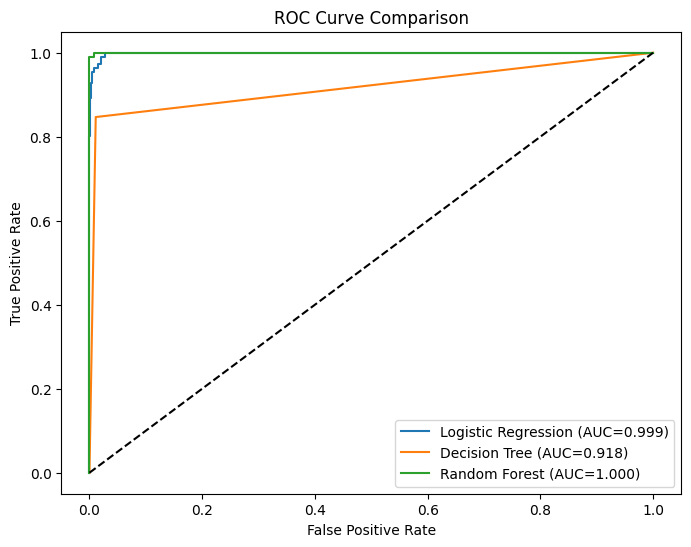

In [95]:
# Probability Scores
lr_prob = lr.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]
rf_prob = best_rf.predict_proba(X_test)[:,1]

# ROC Values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC={roc_auc_score(y_test, dt_prob):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [96]:
auc_scores = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "AUC-ROC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

auc_scores

,Model,AUC-ROC
0,Logistic Regression,0.998831
1,Decision Tree,0.917861
2,Random Forest,0.999922


In [97]:
best_model = auc_scores.sort_values(
    by="AUC-ROC",
    ascending=False
)

best_model

,Model,AUC-ROC
2,Random Forest,0.999922
0,Logistic Regression,0.998831
1,Decision Tree,0.917861


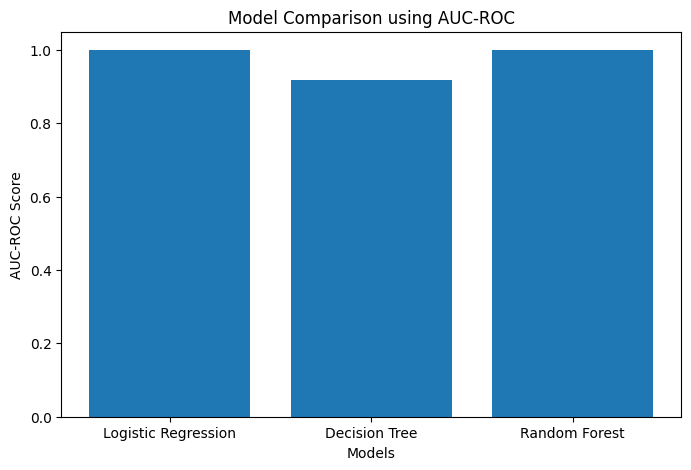

In [98]:
plt.figure(figsize=(8,5))

plt.bar(
    auc_scores["Model"],
    auc_scores["AUC-ROC"]
)

plt.title("Model Comparison using AUC-ROC")
plt.xlabel("Models")
plt.ylabel("AUC-ROC Score")

plt.show()

# Part H: Final Analysis & Reporting

## Best Classification Model and Justification

Multiple classification models including Logistic Regression, Decision Tree, and Random Forest were evaluated for predicting high-risk customers.

Among all models, Random Forest achieved the best overall performance in terms of Accuracy, Recall, F1-Score, and AUC-ROC. The model also demonstrated better generalization capability and reduced overfitting compared to a single Decision Tree. Therefore, Random Forest was selected as the final classification model.

## Impact of Imbalance Handling Techniques

The dataset was highly imbalanced, with high-risk customers representing the minority class.

To address this issue, several balancing techniques were applied:

* Under-Sampling
* Over-Sampling
* SMOTE
* ADASYN

After applying these techniques, the Recall and F1-Score of the minority class improved significantly. SMOTE and ADASYN produced better results because they generated synthetic minority class samples and improved the model’s ability to identify risky customers.

## Comparison of Performance Metrics

The models were evaluated using:

* Accuracy
* Precision
* Recall
* F1-Score
* AUC-ROC

Random Forest achieved the highest overall performance and maintained a better balance between Precision and Recall. The ROC analysis also indicated superior discrimination capability compared to Logistic Regression and Decision Tree models.

## Business Interpretation of False Positives and False Negatives

### False Positive (Type-I Error)

A low-risk customer is incorrectly classified as high-risk.

Business Impact:

* Unnecessary investigation or monitoring.
* Additional operational costs.
* Potential inconvenience to genuine customers.

### False Negative (Type-II Error)

A high-risk customer is incorrectly classified as low-risk.

Business Impact:

* Increased risk of fraud.
* Higher probability of payment default.
* Financial losses to the organization.

Since missing a risky customer can have severe consequences, minimizing False Negatives is more important than minimizing False Positives.

## Final Conclusion and Recommendation

Based on the experimental results, Random Forest was selected as the final model for deployment.

The use of imbalance handling techniques improved minority-class detection and increased the model’s effectiveness in identifying high-risk customers. Considering the business objective of minimizing False Negatives, the final recommended solution is the tuned Random Forest model combined with an appropriate class-balancing technique such as SMOTE.
